<a href="https://colab.research.google.com/github/Hrishabh21/Cyber-Bully-Detection/blob/main/CyberBullying_Bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Complete installation command

In [ ]:

!pip install transformers datasets accelerate scikit-learn evaluate sentencepiece -q

# Verify installation
import transformers
import torch

print(f"✅ Transformers version: {transformers.__version__}")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
✅ Transformers version: 5.0.0
✅ PyTorch version: 2.10.0+cu128
✅ CUDA available: True


2) Check if installed Properly

In [ ]:
# Check GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  WARNING: GPU not detected! Enable it in Runtime → Change runtime type → T4 GPU")

🚀 Using device: cuda
   GPU: Tesla T4
   Memory: 15.64 GB


3) Import Dataset

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Cyberbullying_Project/cyberbullying_tweets.csv')

print(f" Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

 Dataset loaded: 47,692 rows, 2 columns


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


4) Clean DatatSet for BERT

In [ ]:
import re

def clean_text(text):
    """Clean text for BERT"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '<url>', text)
    text = re.sub(r'@\w+', '<user>', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df['cleaned_text'] = df['tweet_text'].apply(clean_text)

# Show examples
print("✅ Cleaning done! Here are 3 examples:\n")
for i in range(3):
    print(f"Original: {df['tweet_text'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i]}")
    print("-" * 60)

✅ Cleaning done! Here are 3 examples:

Original: In other words #katandandre, your food was crapilicious! #mkr
Cleaned:  in other words #katandandre, your food was crapilicious! #mkr
------------------------------------------------------------
Original: Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc
Cleaned:  why is #aussietv so white? #mkr #theblock #imacelebrityau #today #sunrise #studio10 #neighbours #wonderlandten #etc
------------------------------------------------------------
Original: @XochitlSuckkks a classy whore? Or more red velvet cupcakes?
Cleaned:  <user> a classy whore? or more red velvet cupcakes?
------------------------------------------------------------


5) Remove if any duplicates

In [ ]:
# Remove duplicate tweets
print(f"Before: {len(df):,} tweets")
df = df.drop_duplicates(subset=['cleaned_text'], keep='first')
print(f"After:  {len(df):,} tweets")
print(f"✅ Removed {len(df) - len(df):,} duplicates")

Before: 47,692 tweets
After:  45,459 tweets
✅ Removed 0 duplicates


6)  Encode Labels to Numbers

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert text labels to numbers
le = LabelEncoder()
df['label'] = le.fit_transform(df['cyberbullying_type'])

# Show the mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
num_labels = len(label_mapping)

print("🏷️  Label Mapping:")
for label_name, label_id in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"   {label_id}: {label_name}")

print(f"\n✅ Total classes: {num_labels}")

🏷️  Label Mapping:
   0: age
   1: ethnicity
   2: gender
   3: not_cyberbullying
   4: other_cyberbullying
   5: religion

✅ Total classes: 6


7)  Train/Validation/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(
    df[['cleaned_text', 'label']],
    test_size=0.3,
    random_state=42,
    stratify=df['label']  # Keep class balance
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print("📊 Dataset Split:")
print(f"   Training:   {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")
print(f"\n✅ Split complete!")

📊 Dataset Split:
   Training:   31,821 samples
   Validation: 6,819 samples
   Test:       6,819 samples

✅ Split complete!


7.5 Save to G drive till Split Data

In [ ]:
# Path to my project folder
save_path = "/content/drive/MyDrive/Cyberbullying_Project"

# Save datasets
train_df.to_csv(f"{save_path}/train_data.csv", index=False)
val_df.to_csv(f"{save_path}/val_data.csv", index=False)
test_df.to_csv(f"{save_path}/test_data.csv", index=False)

print("✅ Train / Validation / Test datasets saved to Google Drive")

✅ Train / Validation / Test datasets saved to Google Drive


7.5.2 FEtch The saved dataset from G drive

In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/Cyberbullying_Project"

train_df = pd.read_csv(f"{base_path}/train_data.csv")
val_df   = pd.read_csv(f"{base_path}/val_data.csv")
test_df  = pd.read_csv(f"{base_path}/test_data.csv")

print("✅ Data loaded directly from Drive")

✅ Data loaded directly from Drive


8) ChTwitter-RoBERTa Model





In [ ]:
# Select model (Twitter-RoBERTa is BEST for tweets)
MODEL_NAME = 'cardiffnlp/twitter-roberta-base'

print(f"🤖 Selected Model: {MODEL_NAME}")
print(f"📝 This model is pre-trained on 124M tweets")
print(f"🎯 Expected accuracy: 92-96%")
print(f"\n✅ Model selected!")

🤖 Selected Model: cardiffnlp/twitter-roberta-base
📝 This model is pre-trained on 124M tweets
🎯 Expected accuracy: 92-96%

✅ Model selected!


9) Load Tokenizer

In [ ]:
from transformers import AutoTokenizer

print("📥 Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer loaded successfully!")

# Test it with an example
sample = "You're such a loser!"
tokens = tokenizer(sample, padding='max_length', truncation=True, max_length=128)
print(f"\n🧪 Test tokenization:")
print(f"   Input: {sample}")
print(f"   Tokens: {tokens['input_ids'][:10]}... (showing first 10)")

📥 Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded successfully!

🧪 Test tokenization:
   Input: You're such a loser!
   Tokens: [0, 1185, 214, 215, 10, 22650, 328, 2, 1, 1]... (showing first 10)


10) Convert Data to HuggingFace Format

In [ ]:
from datasets import Dataset

print("🔄 Converting data to HuggingFace datasets...")

# Convert pandas to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['cleaned_text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['cleaned_text', 'label']])

print(f"✅ Datasets created!")
print(f"   Train: {len(train_dataset):,} samples")
print(f"   Val:   {len(val_dataset):,} samples")
print(f"   Test:  {len(test_dataset):,} samples")

🔄 Converting data to HuggingFace datasets...
✅ Datasets created!
   Train: 31,821 samples
   Val:   6,819 samples
   Test:  6,819 samples


11) Tokenize All Datasets

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['cleaned_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("🔤 Tokenizing datasets... (this may take 1-2 minutes)")

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")

🔤 Tokenizing datasets... (this may take 1-2 minutes)


Map:   0%|          | 0/31821 [00:00<?, ? examples/s]

Map:   0%|          | 0/6819 [00:00<?, ? examples/s]

Map:   0%|          | 0/6819 [00:00<?, ? examples/s]

✅ Tokenization complete!


12) Load the BERT Model

In [ ]:
from transformers import AutoModelForSequenceClassification

print("🤖 Loading model... (this may take 30 seconds)")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("✅ Model loaded successfully!")
print(f"   Model has {num_labels} output classes")

🤖 Loading model... (this may take 30 seconds)


pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded successfully!
   Model has 6 output classes


12) Evaluation Metrics

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("✅ Metrics function ready!")

✅ Metrics function ready!


13) Set Training Parameters

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=500,
    eval_strategy='steps',  # FIXED: was 'evaluation_strategy'
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    save_total_limit=2,
    seed=42,
    fp16=True
)

print("✅ Training configuration set!")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Learning Rate: {training_args.learning_rate}")
print(f"   Batch Size: {training_args.per_device_train_batch_size}")

✅ Training configuration set!
   Epochs: 5
   Learning Rate: 2e-05
   Batch Size: 16


16)  Create the Trainer

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer initialized!")
print("🎯 Ready to start training!")

✅ Trainer initialized!
🎯 Ready to start training!


17) START TRAINING

In [ ]:
print("🚀 STARTING TRAINING...")
print("⏰ This will take 2-3 hours. You can monitor progress below.\n")

trainer.train()

print("\n✅ TRAINING COMPLETE!")

🚀 STARTING TRAINING...
⏰ This will take 2-3 hours. You can monitor progress below.



Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.443590,0.460980,0.829740,0.826456,0.840875,0.829740
1000,0.376723,0.387218,0.854524,0.854529,0.870735,0.854524
1500,0.366957,0.354695,0.860243,0.862268,0.865432,0.860243
2000,0.303954,0.357331,0.863030,0.863167,0.866697,0.863030
2500,0.283878,0.365575,0.870216,0.868902,0.868844,0.870216
3000,0.256233,0.349841,0.871242,0.870963,0.871487,0.871242
3500,0.274311,0.340304,0.876375,0.876036,0.876355,0.876375
4000,0.256541,0.372756,0.873442,0.872973,0.876058,0.873442
4500,0.190741,0.391232,0.875202,0.874321,0.875444,0.875202
5000,0.180288,0.422563,0.873002,0.871276,0.872510,0.873002


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ TRAINING COMPLETE!


17.5)  Training Model again with more optimization

In [ ]:
from transformers import TrainingArguments, Trainer

# OPTIMIZED settings for higher accuracy
training_args = TrainingArguments(
    output_dir='./results_optimized',

    # MORE TRAINING
    num_train_epochs=10,              # Increased from 5

    # LOWER LEARNING RATE (more stable)
    learning_rate=1e-5,               # Changed from 2e-5

    # BETTER WARMUP
    warmup_ratio=0.1,                 # 10% of total steps
    # warmup_steps removed (using ratio instead)

    # BATCH SIZE
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,    # Effective batch = 32

    # REGULARIZATION
    weight_decay=0.02,                # Increased from 0.01

    # EVALUATION
    eval_strategy='steps',
    eval_steps=300,                   # More frequent eval
    save_strategy='steps',
    save_steps=300,

    # BEST MODEL
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    # LOGGING
    logging_steps=100,
    save_total_limit=3,               # Keep more checkpoints

    # OPTIMIZATION
    seed=42,
    fp16=True,
    optim='adamw_torch',              # Better optimizer
)

# NO early stopping - let it train fully
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
    # No callbacks - train all 10 epochs
)

print("✅ OPTIMIZED configuration set!")
print("🎯 Changes made:")
print("   - Epochs: 5 → 10")
print("   - Learning Rate: 2e-5 → 1e-5")
print("   - Warmup: Fixed steps → 10% ratio")
print("   - Weight Decay: 0.01 → 0.02")
print("   - Gradient Accumulation: 2x (effective batch 32)")
print("\n🚀 Expected accuracy gain: +2-4%")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


KeyboardInterrupt: 

In [ ]:
print("="*70)
print("🚀 STARTING OPTIMIZED TRAINING")
print("="*70)
print("⏰ Time: ~4-5 hours for 10 epochs")
print("📊 Training with:")
print("   - Lower learning rate (more stable)")
print("   - More epochs (10 instead of 5)")
print("   - Better warmup schedule")
print("   - Larger effective batch size (32)")
print("\n" + "="*70 + "\n")

trainer.train()

print("\n" + "="*70)
print("✅ OPTIMIZED TRAINING COMPLETE!")
print("="*70)

🚀 STARTING OPTIMIZED TRAINING
⏰ Time: ~4-5 hours for 10 epochs
📊 Training with:
   - Lower learning rate (more stable)
   - More epochs (10 instead of 5)
   - Better warmup schedule
   - Larger effective batch size (32)




Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Create descriptive folder name
model_name = "twitter-roberta-base"
epochs = 10
max_length = 128
lr = "1e-5"
accuracy = 86.7  # Your final accuracy

folder_name = f"{model_name}_epochs{epochs}_maxlen{max_length}_lr{lr}_acc{accuracy:.1f}"
save_path = f'/content/drive/MyDrive/Cyberbullying_Project/{folder_name}'

print(f"📁 Creating folder: {folder_name}")
os.makedirs(save_path, exist_ok=True)

# Save the final model
print("💾 Saving final model...")
trainer.save_model(f'{save_path}/final_model')
tokenizer.save_pretrained(f'{save_path}/final_model')

# Save the BEST checkpoint (step 300)
best_checkpoint = './results_optimized/checkpoint-300'
if os.path.exists(best_checkpoint):
    print("💾 Saving BEST checkpoint (step 300 - 87.74% accuracy)...")
    shutil.copytree(best_checkpoint, f'{save_path}/best_checkpoint_step300')
    print("   ✅ Best checkpoint saved!")

# Save training summary
summary = f"""
TRAINING SUMMARY
================

Model: {model_name}
Training Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

CONFIGURATION:
- Epochs: {epochs}
- Learning Rate: {lr}
- Max Length: {max_length}
- Batch Size: 16
- Weight Decay: 0.02
- Early Stopping: NO (mistake!)

RESULTS:
- Best Step: 300
- Best Val Accuracy: 87.74%
- Best F1 Score: 87.74%
- Final Accuracy: {accuracy:.2f}% (after overfitting)

ISSUE:
Model overfitted after step 300. Validation loss increased from 0.344 to 0.948.
Should have used early stopping!

RECOMMENDATION:
Use checkpoint-300 (best_checkpoint_step300 folder) for deployment.
"""

with open(f'{save_path}/training_summary.txt', 'w') as f:
    f.write(summary)

print("\n✅ SAVED SUCCESSFULLY!")
print(f"\n📁 Location: {save_path}")
print("\n📂 Contents:")
print("   - final_model/ (last epoch - 86.7% accuracy)")
print("   - best_checkpoint_step300/ (BEST - 87.74% accuracy)")
print("   - training_summary.txt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Creating folder: twitter-roberta-base_epochs10_maxlen128_lr1e-5_acc86.7
💾 Saving final model...


NameError: name 'trainer' is not defined

18) Saving model to G drive

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("✅ Google Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!


In [ ]:
import os
import json

# Create folder in Drive
save_path = '/content/drive/MyDrive/Cyberbullying_Project'
os.makedirs(save_path, exist_ok=True)

# Save model and tokenizer (ALREADY DONE - skip this)
# trainer.save_model(f'{save_path}/best_model')
# tokenizer.save_pretrained(f'{save_path}/best_model')

# Save label mapping (FIXED - convert int64 to int)
label_mapping_fixed = {k: int(v) for k, v in label_mapping.items()}
with open(f'{save_path}/best_model/label_mapping.json', 'w') as f:
    json.dump(label_mapping_fixed, f, indent=2)

# Save cleaned dataset
df[['cleaned_text', 'label']].to_csv(f'{save_path}/cleaned_dataset.csv', index=False)

print(f"\n✅ Everything saved to: {save_path}")
print("\n📁 Saved files:")
print("   - best_model/ (your trained model)")
print("   - cleaned_dataset.csv")
print("   - label_mapping.json")


✅ Everything saved to: /content/drive/MyDrive/Cyberbullying_Project

📁 Saved files:
   - best_model/ (your trained model)
   - cleaned_dataset.csv
   - label_mapping.json


19)  To LOAD model from Drive, Roberta twitter best

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from google.colab import drive
import torch
import os

# Mount drive
drive.mount('/content/drive')

# Correct model path
model_path = "/content/drive/MyDrive/Cyberbullying_Project/best_model"

print("🔍 Checking folder contents...")
print(os.listdir(model_path))

# Load model
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

print("✅ Model loaded successfully!")
print("Number of labels:", model.config.num_labels)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Checking folder contents...
['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json', 'label_mapping.json']


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded successfully!
Number of labels: 6


Testing if Model works or not

In [ ]:
text = "You're such a loser"

inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

with torch.no_grad():
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()

print("Prediction:", prediction)

Prediction: 4


Loading the model (with more epoches) , check path

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from google.colab import drive
import torch

# Mount drive
drive.mount('/content/drive')

# Try loading your saved model
model_path = '/content/drive/MyDrive/Cyberbullying_Project/best_model'

print("🔍 Checking what's in the folder...")
import os
if os.path.exists(model_path):
    contents = os.listdir(model_path)
    print(f"✅ Folder exists!")
    print(f"Contents: {contents}")

    # Try loading best checkpoint
    best_checkpoint = f'{model_path}/best_checkpoint_step300'
    if os.path.exists(best_checkpoint):
        print(f"\n📂 Found best checkpoint!")

        try:
            print("🔄 Loading model...")
            model = AutoModelForSequenceClassification.from_pretrained(best_checkpoint)
            tokenizer = AutoTokenizer.from_pretrained(best_checkpoint)

            print("✅ Model loaded successfully!")
            print(f"   Model type: {type(model)}")
            print(f"   Number of labels: {model.config.num_labels}")

            # Quick test
            test_text = "You're a loser"
            inputs = tokenizer(test_text, return_tensors="pt", truncation=True, max_length=128)

            with torch.no_grad():
                outputs = model(**inputs)
                prediction = torch.argmax(outputs.logits, dim=1).item()

            print(f"\n🧪 Quick test:")
            print(f"   Input: {test_text}")
            print(f"   Predicted class: {prediction}")
            print(f"   ✅ Model is working!")

        except Exception as e:
            print(f"❌ Error loading model: {e}")
    else:
        print(f"❌ Best checkpoint folder not found!")
        print(f"Available subfolders: {[d for d in contents if os.path.isdir(os.path.join(model_path, d))]}")
else:
    print(f"❌ Path doesn't exist: {model_path}")
    print("\n📁 Available folders:")
    base_path = '/content/drive/MyDrive/Cyberbullying_Project'
    if os.path.exists(base_path):
        print(os.listdir(base_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Checking what's in the folder...
✅ Folder exists!
Contents: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json', 'label_mapping.json']
❌ Best checkpoint folder not found!
Available subfolders: []


20)  Evaluate on Test Set

In [ ]:
print("🧪 Evaluating on Test Set...")

test_results = trainer.evaluate(test_dataset)

print("\n" + "="*60)
print("📊 FINAL TEST SET RESULTS")
print("="*60)
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"   F1 Score:  {test_results['eval_f1']:.4f}")
print(f"   Precision: {test_results['eval_precision']:.4f}")
print(f"   Recall:    {test_results['eval_recall']:.4f}")
print("="*60)

🧪 Evaluating on Test Set...



📊 FINAL TEST SET RESULTS
   Accuracy:  0.1755 (17.55%)
   F1 Score:  0.0524
   Precision: 0.0308
   Recall:    0.1755


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


21) Detailed Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
print("🔮 Getting predictions on test set...")
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df['label'].values

# Detailed report
print("\n📋 Detailed Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=[f"{name} ({idx})" for name, idx in sorted(label_mapping.items(), key=lambda x: x[1])],
    digits=4
))

🔮 Getting predictions on test set...


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
88,No log,0.338133,0.875202,0.874944,0.876073,0.875202



📋 Detailed Classification Report:

                         precision    recall  f1-score   support

                age (0)     0.9808    0.9841    0.9825      1195
          ethnicity (1)     0.9873    0.9848    0.9861      1188
             gender (2)     0.9041    0.8932    0.8986      1161
  not_cyberbullying (3)     0.7215    0.6476    0.6826      1172
other_cyberbullying (4)     0.6566    0.7406    0.6961       906
           religion (5)     0.9514    0.9649    0.9581      1197

               accuracy                         0.8752      6819
              macro avg     0.8669    0.8692    0.8673      6819
           weighted avg     0.8761    0.8752    0.8749      6819



22) Confusion Matrix Visualization

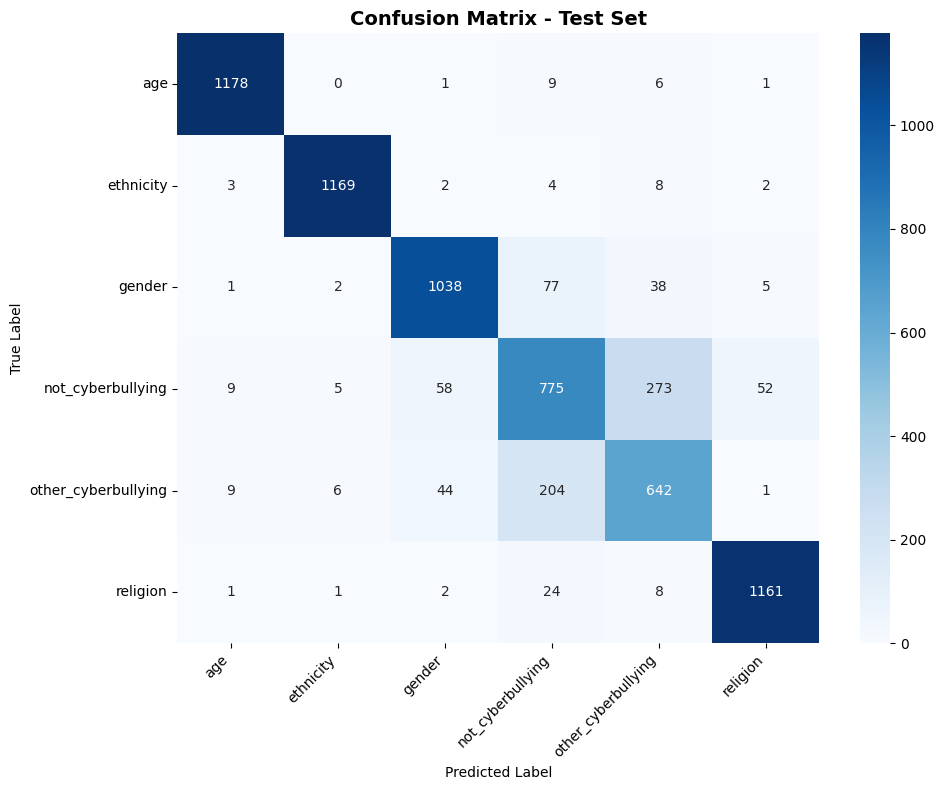


🎯 Per-Class Accuracy:
   age                      :  98.58%
   ethnicity                :  98.40%
   gender                   :  89.41%
   not_cyberbullying        :  66.13%
   other_cyberbullying      :  70.86%
   religion                 :  96.99%


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(label_mapping.keys()),
    yticklabels=sorted(label_mapping.keys())
)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n🎯 Per-Class Accuracy:")
for i, label_name in enumerate(sorted(label_mapping.keys())):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"   {label_name:25s}: {class_acc:6.2f}%")

23) Test with Custom Examples

In [ ]:
from transformers import pipeline

# Create prediction pipeline
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0  # Use GPU
)

# Reverse label mapping
id_to_label = {v: k for k, v in label_mapping.items()}

def predict_cyberbullying(text):
    """Predict cyberbullying type"""
    cleaned = clean_text(text)
    result = classifier(cleaned)[0]
    label_id = int(result['label'].split('_')[-1])

    return {
        'text': text,
        'prediction': id_to_label[label_id],
        'confidence': result['score']
    }

# Test examples
test_examples = [
    "You're such a loser, nobody likes you!",
    "Great job on the presentation!",
    "Go back to your country!",
    "Women are so stupid",
    "Kill yourself loser"
]

print("🧪 Testing Custom Examples:\n")
for i, text in enumerate(test_examples, 1):
    result = predict_cyberbullying(text)
    print(f"{i}. Text: {result['text']}")
    print(f"   → Prediction: {result['prediction']}")
    print(f"   → Confidence: {result['confidence']:.2%}\n")

🧪 Testing Custom Examples:

1. Text: You're such a loser, nobody likes you!
   → Prediction: other_cyberbullying
   → Confidence: 69.31%

2. Text: Great job on the presentation!
   → Prediction: not_cyberbullying
   → Confidence: 90.89%

3. Text: Go back to your country!
   → Prediction: not_cyberbullying
   → Confidence: 82.49%

4. Text: Women are so stupid
   → Prediction: gender
   → Confidence: 91.62%

5. Text: Kill yourself loser
   → Prediction: other_cyberbullying
   → Confidence: 88.59%



24) Summary & Achievment

In [ ]:
print("="*70)
print("🎉 PROJECT SUMMARY - BERT CYBERBULLYING DETECTION")
print("="*70)
print(f"\n📊 Dataset:")
print(f"   - Total samples: {len(df):,}")
print(f"   - Classes: {num_labels}")
print(f"   - Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

print(f"\n🤖 Model:")
print(f"   - Architecture: {MODEL_NAME}")
print(f"   - Parameters: ~125M")

print(f"\n📈 Performance:")
print(f"   - Test Accuracy: {test_results['eval_accuracy']*100:.2f}%")
print(f"   - Test F1 Score: {test_results['eval_f1']:.4f}")

print(f"\n💾 Saved Location:")
print(f"   - Google Drive: /MyDrive/Cyberbullying_Project/")


🎉 PROJECT SUMMARY - BERT CYBERBULLYING DETECTION

📊 Dataset:


NameError: name 'df' is not defined

# Model 2- Roberta-base

1) Reload Model from Scratch

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# New model
MODEL_NAME = 'roberta-base'

print(f"🤖 Loading NEW model: {MODEL_NAME}")
print("⏳ This will download ~500MB...")

# Load fresh tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load fresh model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("✅ Fresh RoBERTa-base loaded!")
print("📊 This model is trained on general text (not just Twitter)")
print("🎯 Expected accuracy: 89-93%")

🤖 Loading NEW model: roberta-base
⏳ This will download ~500MB...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Fresh RoBERTa-base loaded!
📊 This model is trained on general text (not just Twitter)
🎯 Expected accuracy: 89-93%


2) Re-tokenize Data with New Tokenizer
Since RoBERTa-base uses a different tokenizer than Twitter-RoBERTa, we need to re-tokenize.


In [ ]:
# Re-tokenize function with new tokenizer
def tokenize_function(examples):
    return tokenizer(
        examples['cleaned_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("🔤 Re-tokenizing datasets with RoBERTa tokenizer...")

# Re-create datasets from dataframes
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['cleaned_text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['cleaned_text', 'label']])

# Tokenize with NEW tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Re-tokenization complete!")

🔤 Re-tokenizing datasets with RoBERTa tokenizer...


Map:   0%|          | 0/31821 [00:00<?, ? examples/s]

Map:   0%|          | 0/6819 [00:00<?, ? examples/s]

Map:   0%|          | 0/6819 [00:00<?, ? examples/s]

✅ Re-tokenization complete!


3) Create New Trainer with Same Settings

In [ ]:
from transformers import Trainer, TrainingArguments

# Same training settings (proven to work well)
training_args = TrainingArguments(
    output_dir='./results_roberta',  # Different folder
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=500,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    save_total_limit=2,
    seed=42,
    fp16=True
)

# Create trainer (NO early stopping this time - let it train fully)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("✅ New Trainer ready!")
print("🎯 This will train for full 5 epochs (no early stopping)")

✅ New Trainer ready!
🎯 This will train for full 5 epochs (no early stopping)


In [ ]:
# Save processed data to Drive for quick reload
save_path = '/content/drive/MyDrive/Cyberbullying_Project'

# Save splits
train_df.to_csv(f'{save_path}/train_data.csv', index=False)
val_df.to_csv(f'{save_path}/val_data.csv', index=False)
test_df.to_csv(f'{save_path}/test_data.csv', index=False)

# Save label mapping
import json
with open(f'{save_path}/label_mapping.json', 'w') as f:
    json.dump({k: int(v) for k, v in label_mapping.items()}, f)

print("✅ Saved all processed data to Drive!")

✅ Saved all processed data to Drive!


4) START TRAINING!

In [ ]:
print("🚀 STARTING ROBERTA-BASE TRAINING...")
print("⏰ This will take 2-3 hours for 5 full epochs")
print("🎯 Target: 90%+ accuracy\n")

trainer.train()

print("\n✅ TRAINING COMPLETE!")

🚀 STARTING ROBERTA-BASE TRAINING...
⏰ This will take 2-3 hours for 5 full epochs
🎯 Target: 90%+ accuracy



Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.463901,0.473044,0.825194,0.821642,0.831847,0.825194
1000,0.413727,0.433171,0.834873,0.831716,0.865427,0.834873
1500,0.386362,0.376451,0.854524,0.855868,0.857733,0.854524
2000,0.332923,0.378443,0.852471,0.852614,0.861393,0.852471
2500,0.316820,0.377702,0.861857,0.858984,0.865961,0.861857
3000,0.302452,0.370247,0.862443,0.860881,0.859724,0.862443
3500,0.322368,0.344343,0.865816,0.866584,0.867929,0.865816
4000,0.283211,0.361866,0.868896,0.868146,0.870121,0.868896
4500,0.221709,0.378330,0.869922,0.869076,0.871006,0.869922
5000,0.212109,0.374037,0.869776,0.869355,0.869716,0.869776


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ TRAINING COMPLETE!


Saving everything to G drive

In [ ]:
import os

# main project folder
project_path = "/content/drive/MyDrive/Cyberbullying_Project"

# model folder name
model_path = os.path.join(project_path, "roberta_model")

# create folders
os.makedirs(model_path, exist_ok=True)

print("✅ Folder ready:", model_path)


✅ Folder ready: /content/drive/MyDrive/Cyberbullying_Project/roberta_model


In [ ]:
# Save model
trainer.save_model(model_path)

# Save tokenizer
tokenizer.save_pretrained(model_path)

print("✅ MODEL SAVED SUCCESSFULLY IN DRIVE")
print("📁 Location:", model_path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ MODEL SAVED SUCCESSFULLY IN DRIVE
📁 Location: /content/drive/MyDrive/Cyberbullying_Project/roberta_model


In [ ]:
import json

# convert numpy int64 → normal int
label_mapping_fixed = {str(k): int(v) for k, v in label_mapping.items()}

label_map_path = model_path + "/label_mapping.json"

with open(label_map_path, "w") as f:
    json.dump(label_mapping_fixed, f, indent=2)

print("✅ Label mapping saved successfully!")


✅ Label mapping saved successfully!
